# Praktikum


####  Import Library dan Load Dataset Iris

Pada tahap awal, beberapa library yang dibutuhkan diimport terlebih dahulu. Setelah itu dataset Iris diambil menggunakan `load_iris()` dari Scikit-Learn. Dataset ini akan digunakan untuk melakukan klasifikasi menggunakan algoritma KNN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates

# Load dataset Iris dari scikit-learn
iris = load_iris()

#### Konversi Data ke DataFrame

Data Iris yang sudah diambil kemudian diubah ke dalam bentuk DataFrame agar lebih mudah digunakan. Setelah itu ditambahkan kolom `Species` untuk menunjukkan jenis spesies pada setiap data.

In [2]:
# Konversi data menjadi DataFrame Pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target_names[iris.target]

# Definisikan X (fitur) dan y (target/label)
X = df.drop(columns=["Species"])
y = df["Species"]

print(X)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


#### Membuat Parallel Coordinates Plot

Feature space pada dataset Iris memiliki 4 dimensi, yaitu sepal length (cm), sepal width (cm), petal length (cm), dan petal width (cm). Oleh karena itu, digunakan Parallel Coordinates Plot untuk memvisualisasikan data berdimensi tinggi.

In [3]:
# Plot Parallel Coordinates
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Grafik Parallel Coordinates digunakan untuk melihat pola dari setiap data berdasarkan 4 fitur yang ada pada dataset Iris. Setiap kelas spesies ditampilkan dengan warna yang berbeda.

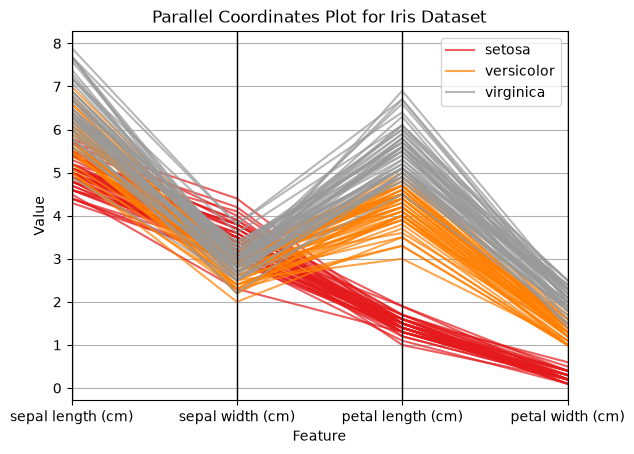

In [4]:
parallel_coordinates(df, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot for Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()

#### Mengubah Label Menjadi Data Numerik

Label pada variabel `y` masih berupa teks, yaitu nama spesies bunga. Oleh karena itu, label tersebut diubah menjadi bentuk angka menggunakan `LabelEncoder` agar dapat digunakan dalam proses klasifikasi.

In [5]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
y = lab.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

#### Membagi Data Training dan Data Testing

Data dibagi menjadi data training dan data testing dengan perbandingan 80% untuk training dan 20% untuk testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk melihat hasil prediksi model.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

#### Membuat Model KNN

Pada tahap ini digunakan algoritma K-Nearest Neighbors (KNN) untuk melakukan klasifikasi. Nilai `k` yang digunakan adalah 3, sedangkan jarak antar data menggunakan Euclidean.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# k = 3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### Melakukan Prediksi

Setelah model KNN selesai dilatih, model digunakan untuk memprediksi kelas dari data testing. Hasil prediksi kemudian disimpan pada variabel `y_pred`.

In [8]:
y_pred = knn.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

#### Menghitung Akurasi

Setelah mendapatkan hasil prediksi, akurasi model dihitung dengan membandingkan hasil prediksi dengan label sebenarnya pada data testing.

In [9]:
result = accuracy_score(y_test, y_pred)
result

0.9666666666666667

#### Membaca Dataset athletes.csv

Pada bagian ini digunakan dataset `athletes.csv`. Dataset tersebut digunakan untuk menentukan apakah seorang atlet masuk draft atau tidak berdasarkan nilai speed dan agility.

In [ ]:
df = pd.read_csv('athletes.csv')
print(df)

    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


#### Menentukan Fitur dan Target

Dari dataset tersebut, `speed` dan `agility` digunakan sebagai fitur yang menjadi input untuk model. Sementara itu, `draft` digunakan sebagai target yang akan diprediksi.

In [12]:
feature_columns = ['speed', 'agility']
X = df[feature_columns].values
y = df['draft'].values
X

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

#### Melihat Data Target

Variabel `y` digunakan untuk melihat nilai target pada dataset. Target yang digunakan terdiri dari dua kelas, yaitu `yes` dan `no`.

In [13]:
y

<StringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

#### Mengubah Data Target Menjadi Numerik

Data target yang sebelumnya berupa teks diubah menjadi angka menggunakan `LabelEncoder`. Perubahan ini dilakukan agar label dapat digunakan dalam proses klasifikasi KNN.

In [14]:
#encode data y menjadi numerik
en = LabelEncoder()
y = en.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

#### Menambahkan Label ke DataFrame dan Menentukan Warna

Pada bagian ini dibuat kolom `key1` yang berisi hasil encoding dari target. Kemudian warna ditentukan berdasarkan nilai tersebut agar data `no` dan `yes` dapat dibedakan saat dibuat dalam bentuk scatter plot.

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


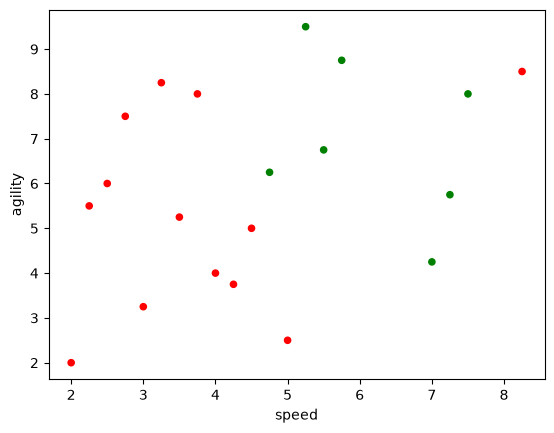

In [15]:
from numpy import where
df['key1'] = (y)
colors = np.where(df["key1"]==0,'r','g')
print(colors)
df.plot.scatter(x=1,y=2,c=colors)
plt.show()

#### Membagi Data Training dan Data Testing

Data dibagi menjadi data training dan data testing dengan `test_size=0.2`, sehingga 20% data digunakan sebagai data testing. Data training digunakan untuk melatih model KNN, sedangkan data testing digunakan untuk melakukan pengujian.

In [16]:
# split train test
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

#### Membuat Model KNN

Pada tahap ini dibuat model KNN dengan nilai `k=5`. Jarak yang digunakan adalah Euclidean. Setelah model dibuat, data training digunakan untuk melatih model.

In [17]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### Melakukan Prediksi

Model yang sudah dilatih kemudian digunakan untuk memprediksi data testing. Hasil prediksi disimpan pada variabel `y_pred`.

In [18]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

#### Menghitung Akurasi

Setelah hasil prediksi diperoleh, dilakukan perhitungan akurasi untuk melihat seberapa banyak prediksi model yang sesuai dengan data sebenarnya.

In [19]:
result = accuracy_score(y_test, y_pred)
result

0.75

#### Mencoba Beberapa Nilai K

Untuk mencari nilai K yang digunakan pada model, dicoba beberapa nilai K dari 1 sampai 10. Setiap nilai K diuji dan hasil akurasinya disimpan untuk kemudian dibandingkan melalui grafik.

Text(0, 0.5, 'Nilai Akurasi')

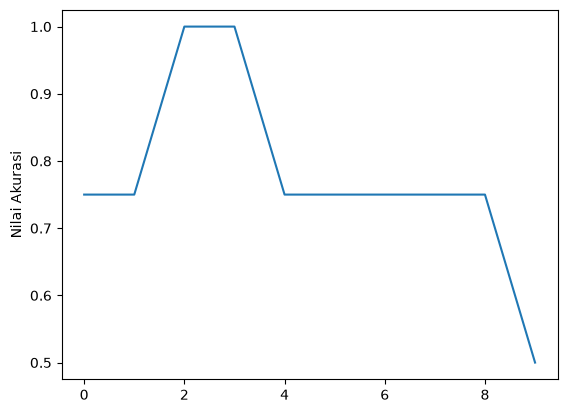

In [20]:
#untuk menemukan nilai K yang tepat, bisa dengan mencoba beberapa variasi nilai k dan melihat akurasinya
array_k = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Calculate accuracy
    result = accuracy_score(y_test, y_pred)

    # Store the accuracy result
    array_k.append(result)

plt.plot(array_k)
plt.ylabel('Nilai Akurasi')

#### Grafik Nilai K dan Akurasi

Grafik dibuat untuk melihat perubahan nilai akurasi pada setiap nilai K yang dicoba. Dengan grafik ini, hasil akurasi dari masing-masing nilai K dapat dibandingkan.

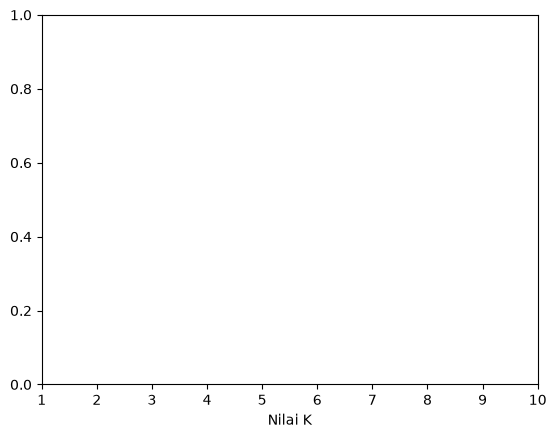

In [21]:
plt.xlabel('Nilai K')
plt.xticks(np.arange(10),('1','2','3','4','5','6','7','8','9','10'))
plt.show()

# TUGAS 

#### Prediksi Data Atlet

Pada bagian ini dilakukan prediksi terhadap dua data atlet untuk menentukan apakah atlet tersebut masuk draft atau tidak. Model KNN menggunakan data speed dan agility sebagai fitur.

In [23]:
# Membuat kembali model KNN dengan k = 5
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

# Prediksi data atlet
input_data = [
    [7.5, 7.0],
    [4.0, 6.5]
]

prediction = knn.predict(input_data)

for data, pred in zip(input_data, prediction):
    print(f"Input {data} -> {'yes' if pred == 1 else 'no'}")

Input [7.5, 7.0] -> yes
Input [4.0, 6.5] -> no


#### Prediksi Dataset Iris

Karena variabel `df` sebelumnya sudah digunakan untuk dataset athletes, data Iris dimuat kembali terlebih dahulu. Setelah itu data dibagi menjadi fitur dan target, lalu dibuat model KNN dengan nilai K = 3 untuk melakukan prediksi pada data yang diberikan.

In [26]:
# Mengembalikan dataset Iris
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target_names[iris.target]

# Definisikan X dan y
X = df.drop(columns=["Species"])
y = df["Species"]

# Encode label
lab = LabelEncoder()
y = lab.fit_transform(y)

# Split data Iris
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

# Membuat model KNN dengan k = 3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

# Data yang akan diprediksi
input_data = [
    [7.1, 1.2, 5.0, 2.0],
    [5.1, 3.5, 1.4, 0.2],
    [6.4, 3.7, 4.2, 2.2]
]

prediction = knn.predict(input_data)

for data, pred in zip(input_data, prediction):
    print(f"Input {data} -> {lab.inverse_transform([pred])[0]}")

Input [7.1, 1.2, 5.0, 2.0] -> virginica
Input [5.1, 3.5, 1.4, 0.2] -> setosa
Input [6.4, 3.7, 4.2, 2.2] -> versicolor


c:\Users\Brahmana P\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
